<a href="https://colab.research.google.com/github/Bokenasubi-T/pomacea-distribution-jp/blob/main/notebooks/07_land_usage.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import geopandas as gpd

In [3]:
from google.colab import drive
drive.mount("/content/drive")
# Project folders on Google Drive
BASE_DIR = "/content/drive/MyDrive/Colab Notebooks/pomacea"
DATA_DIR = f"{BASE_DIR}/data"

Mounted at /content/drive


In [57]:
# check the data structure of land-usage data
!wget -nc -P /content/land_usage https://nlftp.mlit.go.jp/ksj/gml/data/L03-b/L03-b-21/L03-b-21_4929-jgd2011_GML.zip
!unzip -n /content/land_usage/L03-b-21_4929-jgd2011_GML.zip -d /content/land_usage

--2026-10-08 08:35:57--  https://nlftp.mlit.go.jp/ksj/gml/data/L03-b/L03-b-21/L03-b-21_4929-jgd2011_GML.zip
Resolving nlftp.mlit.go.jp (nlftp.mlit.go.jp)... 130.35.228.165, 130.35.103.62, 147.154.45.210
Connecting to nlftp.mlit.go.jp (nlftp.mlit.go.jp)|130.35.228.165|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 17615540 (17M) [application/zip]
Saving to: ‘/content/land_usage/L03-b-21_4929-jgd2011_GML.zip’

L03-b-21_4929-jgd20 100%[===================>]  16.80M  11.2MB/s    in 1.5s    

2026-10-08 08:36:00 (11.2 MB/s) - ‘/content/land_usage/L03-b-21_4929-jgd2011_GML.zip’ saved [17615540/17615540]

Archive:  /content/land_usage/L03-b-21_4929-jgd2011_GML.zip
  inflating: /content/land_usage/L03-b-21_4929.shp  
  inflating: /content/land_usage/L03-b-21_4929.shx  
  inflating: /content/land_usage/L03-b-21_4929.dbf  
  inflating: /content/land_usage/L03-b-21_4929.prj  
  inflating: /content/land_usage/L03-b-21_4929.xml  
  inflating: /content/land_usage/KS-META-L

In [58]:
# check the content
df = gpd.read_file("/content/land_usage/L03-b-21_4929.dbf",ignore_geometry=True)
display(df.dtypes) # data type of each columns
display(df.head()) # check first several rows of dataframe
df['L03b_002'].groupby(df['L03b_002']).count() # number of samples for each land-use attributes


,0
L03b_001,object
L03b_002,object
L03b_003,object


,L03b_001,L03b_002,L03b_003
0,4929000000,1500,20200519
1,4929000001,1500,20200519
2,4929000002,1500,20200519
3,4929000003,1500,20200519
4,4929000004,1500,20200519


,L03b_002
L03b_002,
0100,18328
0200,20864
0500,131065
0600,2216
0700,21063
0901,764
0902,335
1000,5408
1100,2290


<Axes: xlabel='Geodetic longitude [degree]', ylabel='Geodetic latitude [degree]'>

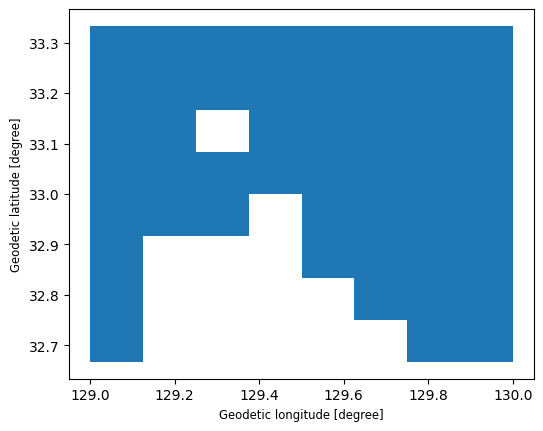

In [30]:
# check the shapes of shape file
chk = gpd.read_file("/content/land_usage/L03-b-21_4929.shp")
chk.plot()

In [66]:
# Get all land-use data across Japan

# get names of all files from data provider website
land_use_row = pd.read_html("https://nlftp.mlit.go.jp/ksj/gml/datalist/KsjTmplt-L03-b-2021.html", attrs = {"class" : "mb30 responsive-table dataTables-mesh"})
land_use_row = land_use_row[0]
#display(land_use_row.columns)


land_use_renamed = land_use_row.rename(columns=lambda x: x.split()[0]) # rename colums name for convenience
land_use_renamed =  land_use_renamed[land_use_renamed["測地系"].isin(["世界測地系"])] # extract newCRS data
land_use_renamed =  land_use_renamed[land_use_renamed["年度"].isin(["2021年（令和3年）"])] # extract 2021 data only

file_name = land_use_renamed['ファイル名']



In [68]:
len(file_name)
file_name.head()
land_use_renamed.head()

,地域,測地系,年度,ファイル容量,ファイル名,ダウンロード,一括DL
1,3036,世界測地系,2021年（令和3年）,0.72MB,L03-b-21_3036-jgd2011_GML.zip,file_download,NaN
15,3622,世界測地系,2021年（令和3年）,0.38MB,L03-b-21_3622-jgd2011_GML.zip,file_download,NaN
29,3623,世界測地系,2021年（令和3年）,3.86MB,L03-b-21_3623-jgd2011_GML.zip,file_download,NaN
43,3624,世界測地系,2021年（令和3年）,4.57MB,L03-b-21_3624-jgd2011_GML.zip,file_download,NaN
57,3631,世界測地系,2021年（令和3年）,0.37MB,L03-b-21_3631-jgd2011_GML.zip,file_download,NaN


In [69]:

container = []

for i in file_name[0:3]:
  path = f"{i[0:5]}/{i[0:8]}/{i}"
  !wget -nc -q -P /content/land_usage https://nlftp.mlit.go.jp/ksj/gml/data/{path}
  !unzip -n /content/land_usage/{i} "*.dbf" -d /content/land_usage
  temp = gpd.read_file(f"/content/land_usage/{i[0:13]}.dbf",ignore_geometry=True)
  temp = temp[["L03b_001","L03b_002"]]
  temp = temp[temp["L03b_002"] != "1500"]
  temp = temp.assign(grid_number = i[9:13])
  container.append(temp)

land_use_master = pd.concat(container)


Archive:  /content/land_usage/L03-b-21_3036-jgd2011_GML.zip
  inflating: /content/land_usage/L03-b-21_3036.dbf  
Archive:  /content/land_usage/L03-b-21_3622-jgd2011_GML.zip
  inflating: /content/land_usage/L03-b-21_3622.dbf  
Archive:  /content/land_usage/L03-b-21_3623-jgd2011_GML.zip
  inflating: /content/land_usage/L03-b-21_3623.dbf  


In [70]:
land_use_master.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
Index: 29819 entries, 2688 to 107517
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   L03b_001     29819 non-null  object
 1   L03b_002     29819 non-null  object
 2   grid_number  29819 non-null  object
dtypes: object(3)
memory usage: 4.9 MB
